## Feature-Dropping Visualization
This cell below implements the required three-stage aggregation:
1. Mean over `context_seed` for each `(seed_feature_drop_rate, fold)`.
2. Mean over `seed_feature_drop_rate` for each fold.
3. Mean and std over folds for plotting.

Rows correspond to scenarios and columns correspond to metrics.

tabpfn: loaded 10850 runs from tabpfn_all_scenarios.pkl
distnet: loaded 9450 runs from distnet_all_scenarios_extended.pkl
random_forest: loaded 10850 runs from random_forest_all_scenarios.pkl


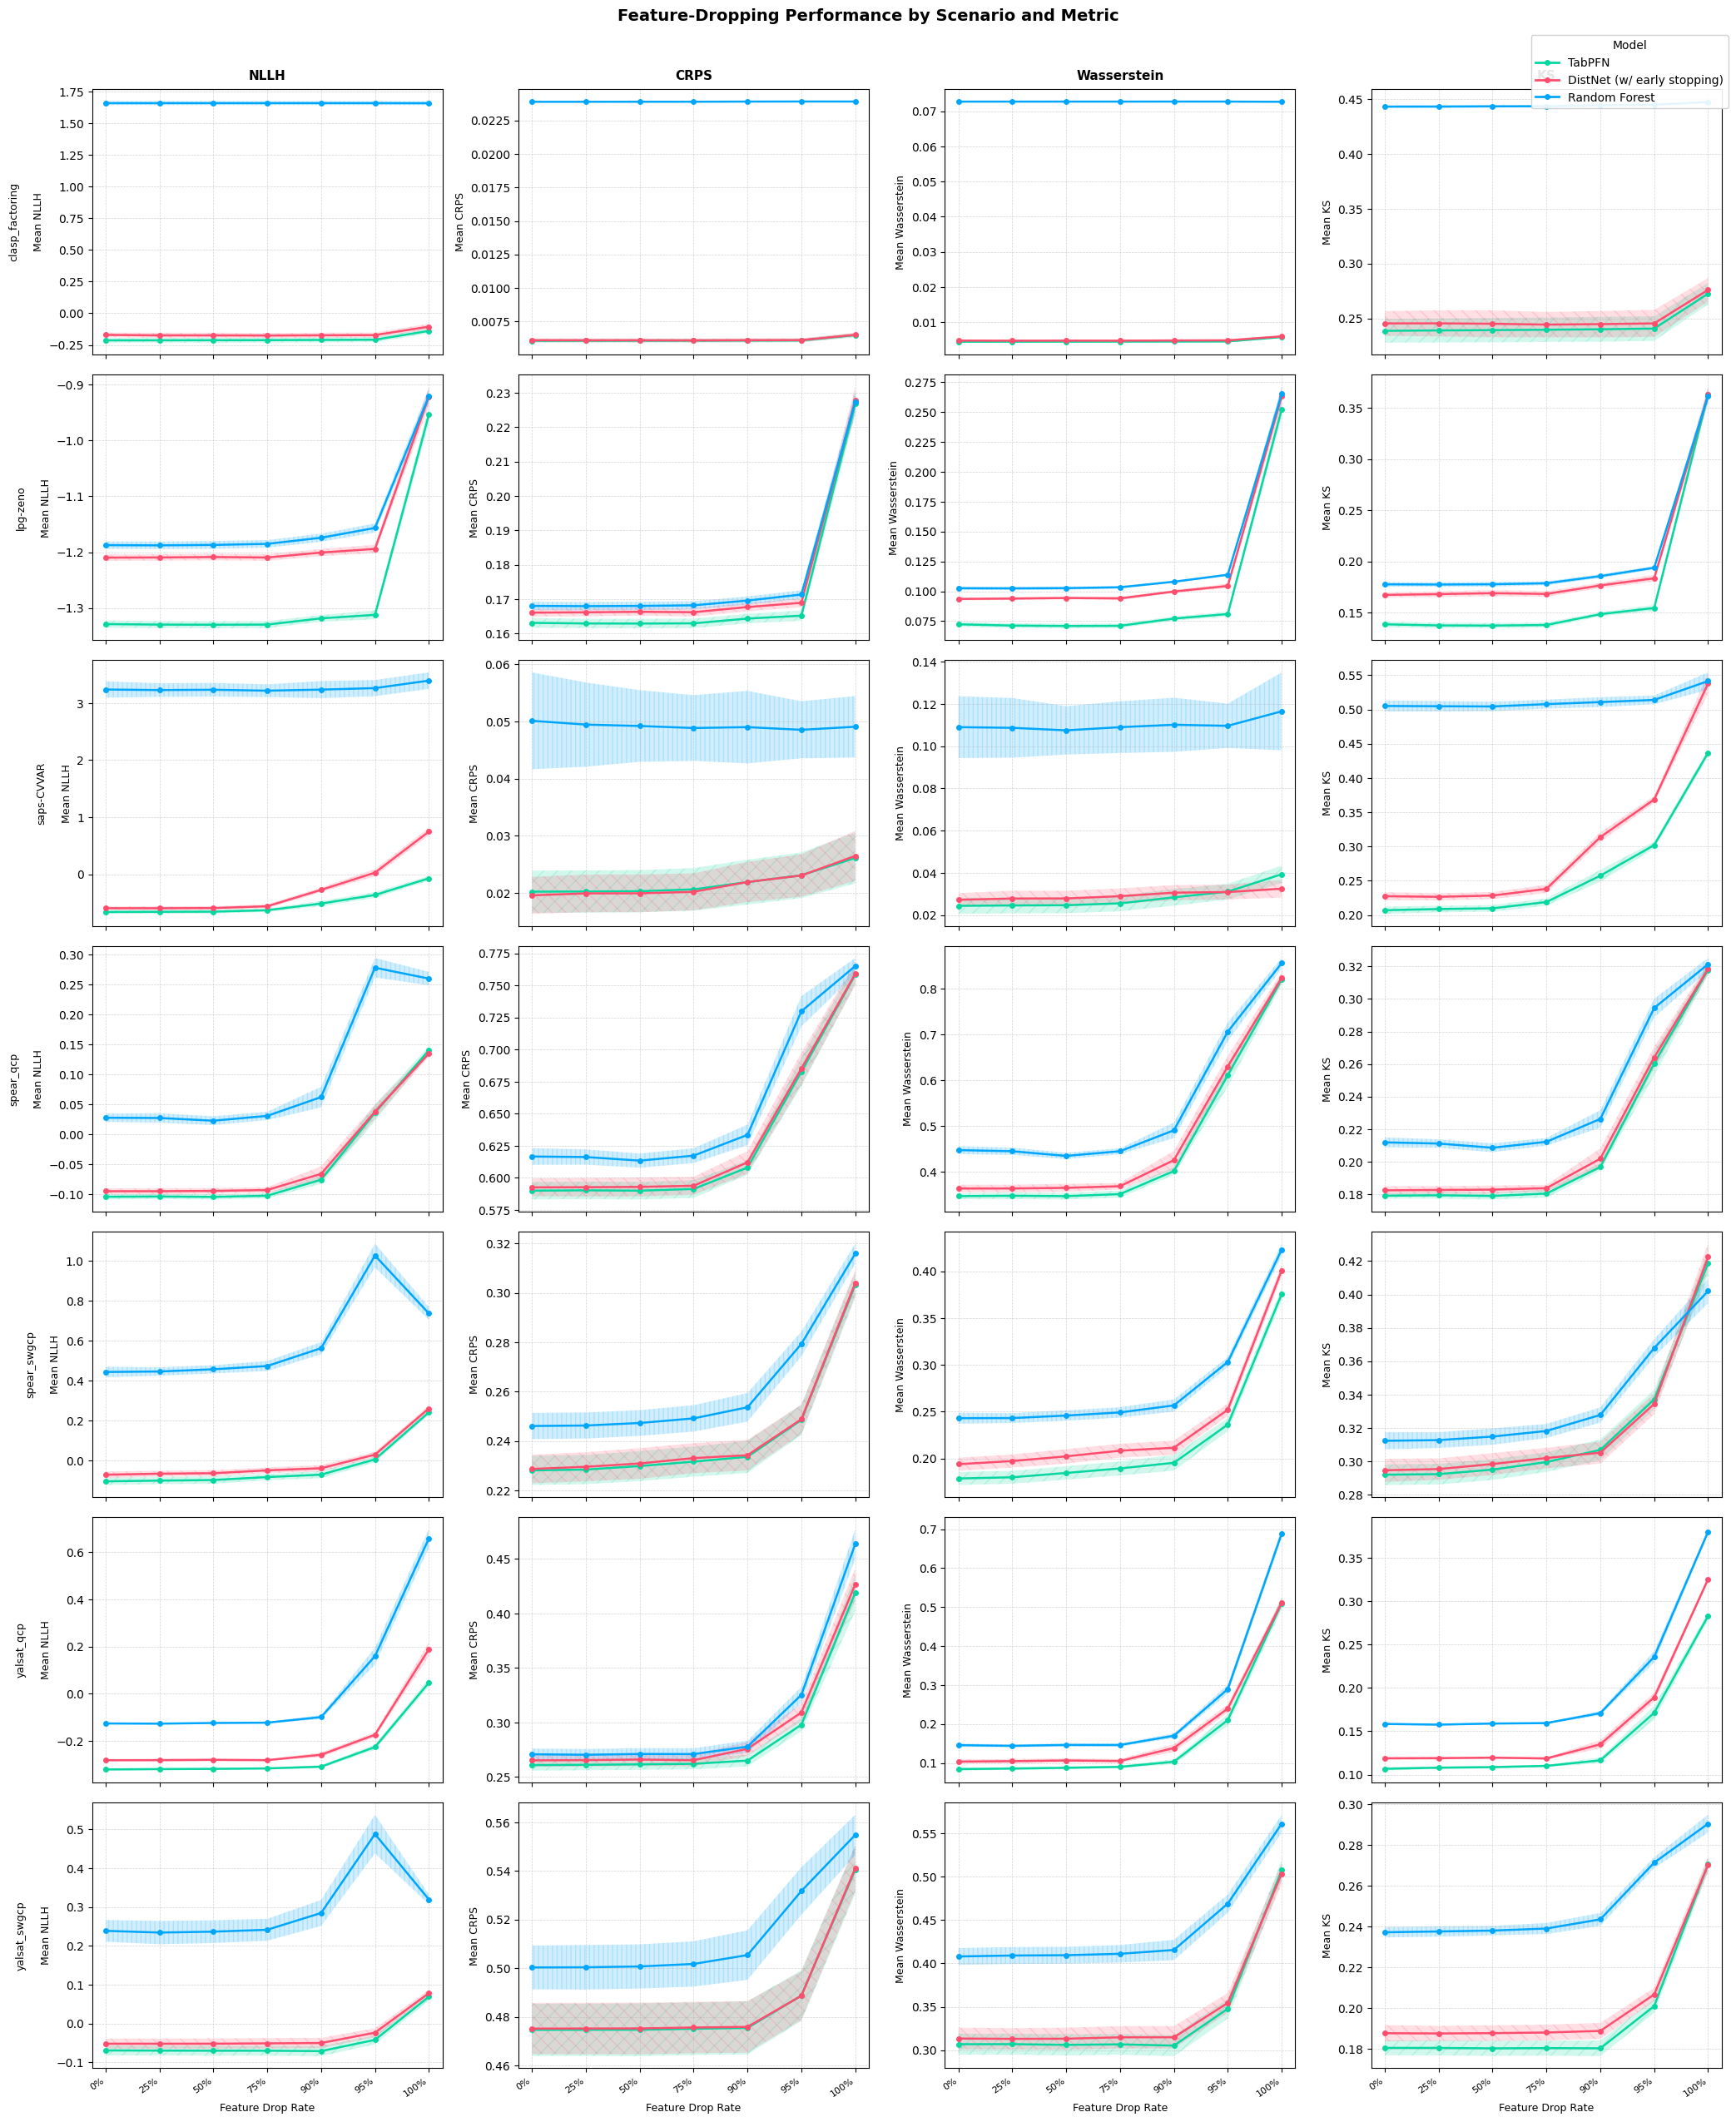

Scenarios: 7 | Metrics: 4 | Drop rates: [0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 1.0]
tabpfn: 196 aggregated (scenario, metric, drop_rate) points
distnet: 196 aggregated (scenario, metric, drop_rate) points
random_forest: 196 aggregated (scenario, metric, drop_rate) points


In [1]:
from collections import defaultdict
import pickle

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from tabpfn_project.paths import RESULTS_DIR

results_dir = RESULTS_DIR / "experiment_feature_dropping"
results_dir.mkdir(parents=True, exist_ok=True)

tabpfn_fdrop_lst_path = results_dir / "tabpfn_all_scenarios.pkl"
distnet_fdrop_lst_path = results_dir / "distnet_all_scenarios_extended.pkl"
random_forest_fdrop_lst_path = results_dir / "random_forest_all_scenarios.pkl"

METRICS = ["NLLH", "CRPS", "Wasserstein", "KS"]
MODELS = ["tabpfn", "distnet", "random_forest"]
MODEL_LABELS = {
    "tabpfn": "TabPFN",
    "distnet": "DistNet (w/ early stopping)",
    "random_forest": "Random Forest",
}
MODEL_COLORS = {
    "tabpfn": "#06D6A0",
    "distnet": "#FF4D6D",
    "random_forest": "#00A6FB",
}
MODEL_HATCHES = {
    "tabpfn": "//",
    "distnet": "\\\\",
    "random_forest": "|||",
}

model_paths = {
    "tabpfn": tabpfn_fdrop_lst_path,
    "distnet": distnet_fdrop_lst_path,
    "random_forest": random_forest_fdrop_lst_path,
}

def to_1d_finite_array(values):
    if values is None:
        return np.array([], dtype=float)
    if hasattr(values, "detach"):
        values = values.detach()
    if hasattr(values, "cpu"):
        values = values.cpu()
    arr = np.asarray(values, dtype=float).ravel()
    return arr[np.isfinite(arr)]

def format_drop_rate(rate):
    pct = rate * 100.0
    if np.isclose(pct, round(pct)):
        return f"{int(round(pct))}%"
    return f"{pct:.1f}%"


results_by_model = {}
for model, pkl_path in model_paths.items():
    with open(pkl_path, "rb") as f:
        results_by_model[model] = pickle.load(f)
    print(f"{model}: loaded {len(results_by_model[model])} runs from {pkl_path.name}")

# Stage 1: mean over context_seed for each (seed_feature_drop_rate, fold).
seed_feature_group_scores = defaultdict(list)
for model, run_list in results_by_model.items():
    for entry in run_list:
        scenario = entry.get("scenario")
        fold = entry.get("fold")
        drop_rate = entry.get("feature_drop_rate")
        seed_drop = entry.get("seed_feature_drop_rate", entry.get("seed_features"))
        inst_summary = entry.get("instance_summary", {})

        if scenario is None or fold is None or drop_rate is None or seed_drop is None:
            continue

        try:
            fold = int(fold)
            drop_rate = float(drop_rate)
            seed_drop = int(seed_drop)
        except (TypeError, ValueError):
            continue

        for metric in METRICS:
            metric_values = to_1d_finite_array(inst_summary.get(metric))
            if metric_values.size == 0:
                continue

            run_score = float(metric_values.mean())
            key = (model, str(scenario), metric, drop_rate, fold, seed_drop)
            seed_feature_group_scores[key].append(run_score)

stage1_means = defaultdict(list)
for key, score_list in seed_feature_group_scores.items():
    model, scenario, metric, drop_rate, fold, _seed_drop = key
    mean_over_context_seeds = float(np.mean(score_list))
    stage1_means[(model, scenario, metric, drop_rate, fold)].append(mean_over_context_seeds)

# Stage 2: mean over seed_feature_drop_rate for each fold.
stage2_fold_scores = defaultdict(list)
for key, seed_drop_scores in stage1_means.items():
    model, scenario, metric, drop_rate, fold = key
    mean_over_seed_feature_drop_rate = float(np.mean(seed_drop_scores))
    stage2_fold_scores[(model, scenario, metric, drop_rate)].append(mean_over_seed_feature_drop_rate)

# Stage 3: mean and std over folds.
plot_data = {}
for key, fold_scores in stage2_fold_scores.items():
    scores = np.asarray(fold_scores, dtype=float)
    mean_over_folds = float(np.mean(scores))
    std_over_folds = float(np.std(scores, ddof=1)) if scores.size > 1 else 0.0
    plot_data[key] = (mean_over_folds, std_over_folds, int(scores.size))

if not plot_data:
    raise RuntimeError("No plottable data found after aggregation.")

scenarios = sorted({k[1] for k in plot_data})
drop_rates = sorted({k[3] for k in plot_data})

# Use evenly spaced categorical x-positions to avoid crowding at high drop rates (e.g., 90/95/100%).
drop_rate_positions = {rate: idx for idx, rate in enumerate(drop_rates)}
drop_rate_labels = [format_drop_rate(rate) for rate in drop_rates]
x_positions = np.arange(len(drop_rates), dtype=float)

n_rows = len(scenarios)
n_cols = len(METRICS)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.2 * n_cols, 3.6 * n_rows),
    squeeze=False,
    sharex=True,
    constrained_layout=False,
)

for row_idx, scenario in enumerate(scenarios):
    for col_idx, metric in enumerate(METRICS):
        ax = axes[row_idx][col_idx]

        for model in MODELS:
            xs, means, stds = [], [], []
            for drop_rate in drop_rates:
                key = (model, scenario, metric, drop_rate)
                if key not in plot_data:
                    continue
                mean_perf, std_perf, _n_folds = plot_data[key]
                xs.append(drop_rate_positions[drop_rate])
                means.append(mean_perf)
                stds.append(std_perf)

            if not xs:
                continue

            xs = np.asarray(xs, dtype=float)
            means = np.asarray(means, dtype=float)
            stds = np.asarray(stds, dtype=float)

            color = MODEL_COLORS[model]
            hatch = MODEL_HATCHES[model]
            ax.plot(
                xs,
                means,
                marker="o",
                markersize=4,
                linewidth=1.8,
                color=color,
                label=MODEL_LABELS[model],
            )
            ax.fill_between(xs, means - stds, means + stds, color=color, alpha=0.18, hatch=hatch, edgecolor="none")

        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.55)
        ax.set_xticks(x_positions)
        ax.set_xlim(-0.25, len(drop_rates) - 0.75)

        if row_idx == n_rows - 1:
            ax.set_xticklabels(drop_rate_labels, rotation=35, ha="right", fontsize=8)
            ax.set_xlabel("Feature Drop Rate", fontsize=9)
        else:
            ax.tick_params(axis="x", labelbottom=False)

        if row_idx == 0:
            ax.set_title(metric, fontsize=11, fontweight="bold", pad=8)

        if col_idx == 0:
            ax.set_ylabel(f"{scenario}\n\nMean {metric}", fontsize=9)
        else:
            ax.set_ylabel(f"Mean {metric}", fontsize=9)

handles = [
    mlines.Line2D(
        [0],
        [0],
        color=MODEL_COLORS[m],
        linewidth=2,
        marker="o",
        markersize=4,
        label=MODEL_LABELS[m],
    )
    for m in MODELS
]
fig.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
    framealpha=0.9,
    fontsize=10,
    ncol=1,
    title="Model",
)

plt.suptitle(
    "Feature-Dropping Performance by Scenario and Metric",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

print(f"Scenarios: {len(scenarios)} | Metrics: {len(METRICS)} | Drop rates: {drop_rates}")
for model in MODELS:
    n_points = sum(1 for key in plot_data if key[0] == model)
    print(f"{model}: {n_points} aggregated (scenario, metric, drop_rate) points")

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display

if "plot_data" not in globals() or not plot_data:
    raise RuntimeError("Run Cell 8 first so `plot_data` is available.")

records = []
for (model, scenario, metric, drop_rate), (mean_perf, std_perf, n_folds) in plot_data.items():
    ci95_half_width = 1.96 * std_perf / np.sqrt(n_folds) if n_folds > 0 else np.nan
    records.append(
        {
            "scenario": scenario,
            "metric": metric,
            "feature_drop_rate": float(drop_rate),
            "model": model,
            "mean_over_folds": float(mean_perf),
            "std_over_folds": float(std_perf),
            "n_folds": int(n_folds),
            "ci95_half_width": float(ci95_half_width),
        }
    )

results_tidy = pd.DataFrame.from_records(records)
results_tidy["feature_drop_rate_pct"] = results_tidy["feature_drop_rate"] * 100.0
results_tidy["feature_drop_rate_label"] = results_tidy["feature_drop_rate_pct"].map(
    lambda x: f"{int(round(x))}%" if np.isclose(x, round(x)) else f"{x:.1f}%"
 )

# Lower is better for all four metrics in this project.
results_tidy["rank_within_group"] = (
    results_tidy.groupby(["scenario", "metric", "feature_drop_rate"])["mean_over_folds"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

results_tidy["mean_pm_std"] = results_tidy.apply(
    lambda r: f"{r['mean_over_folds']:.6f} +/- {r['std_over_folds']:.6f}", axis=1
)

results_tidy = results_tidy.sort_values(
    ["scenario", "metric", "feature_drop_rate", "rank_within_group", "model"]
).reset_index(drop=True)

# Wide-format table for easy reading and reporting.
results_wide = results_tidy.pivot_table(
    index=["scenario", "metric", "feature_drop_rate", "feature_drop_rate_label"],
    columns="model",
    values=["mean_over_folds", "std_over_folds", "n_folds", "rank_within_group", "mean_pm_std"],
    aggfunc="first",
).reset_index()

flat_columns = []
for col in results_wide.columns:
    if isinstance(col, tuple):
        # Columns coming from reset_index() look like ("scenario", "").
        if col[1] == "":
            flat_columns.append(col[0])
        else:
            flat_columns.append(f"{col[1]}_{col[0]}")
    else:
        flat_columns.append(col)
results_wide.columns = flat_columns

results_wide = results_wide.sort_values(
    ["scenario", "metric", "feature_drop_rate"]
).reset_index(drop=True)

csv_path = results_dir / "feature_dropping_results_table.csv"
results_wide.to_csv(csv_path, index=False)

display_cols = [
    "scenario",
    "metric",
    "feature_drop_rate_label",
    "tabpfn_mean_pm_std",
    "distnet_mean_pm_std",
    "random_forest_mean_pm_std",
    "tabpfn_rank_within_group",
    "distnet_rank_within_group",
    "random_forest_rank_within_group",
]
display(results_wide[display_cols])
print(f"Saved table to: {csv_path}")
print(f"Rows: {len(results_wide)}")

,scenario,metric,feature_drop_rate_label,tabpfn_mean_pm_std,distnet_mean_pm_std,random_forest_mean_pm_std,tabpfn_rank_within_group,distnet_rank_within_group,random_forest_rank_within_group
0,clasp_factoring,CRPS,0%,0.006056 +/- 0.000140,0.006096 +/- 0.000146,0.023891 +/- 0.000022,1,2,3
1,clasp_factoring,CRPS,25%,0.006060 +/- 0.000141,0.006092 +/- 0.000149,0.023892 +/- 0.000022,1,2,3
2,clasp_factoring,CRPS,50%,0.006064 +/- 0.000141,0.006093 +/- 0.000148,0.023895 +/- 0.000021,1,2,3
3,clasp_factoring,CRPS,75%,0.006068 +/- 0.000141,0.006085 +/- 0.000140,0.023896 +/- 0.000020,1,2,3
4,clasp_factoring,CRPS,90%,0.006075 +/- 0.000142,0.006100 +/- 0.000147,0.023908 +/- 0.000020,1,2,3
...,...,...,...,...,...,...,...,...,...
191,yalsat_swgcp,Wasserstein,50%,0.306119 +/- 0.012228,0.313194 +/- 0.012747,0.409491 +/- 0.009694,1,2,3
192,yalsat_swgcp,Wasserstein,75%,0.306695 +/- 0.011900,0.314808 +/- 0.012900,0.411091 +/- 0.010103,1,2,3
193,yalsat_swgcp,Wasserstein,90%,0.305243 +/- 0.012163,0.314849 +/- 0.012930,0.415527 +/- 0.011788,1,2,3
194,yalsat_swgcp,Wasserstein,95%,0.347816 +/- 0.011269,0.354472 +/- 0.011356,0.468975 +/- 0.010525,1,2,3


Saved table to: C:\Users\ihagv\Desktop\Study Project UFR\master_project\results\experiment_feature_dropping\feature_dropping_results_table.csv
Rows: 196


In [3]:
import numpy as np
import pandas as pd

target_drop_rate = 0.0
tol = 1e-12

if "results_tidy" in globals():
    debug_df = results_tidy[np.isclose(results_tidy["feature_drop_rate"], target_drop_rate, atol=tol)].copy()
else:
    if "plot_data" not in globals() or not plot_data:
        raise RuntimeError("Run Cell 8 first (and Cell 9 optionally), so aggregated results exist.")
    rows = []
    for (model, scenario, metric, drop_rate), (mean_perf, std_perf, n_folds) in plot_data.items():
        if np.isclose(drop_rate, target_drop_rate, atol=tol):
            rows.append(
                {
                    "scenario": scenario,
                    "model": model,
                    "metric": metric,
                    "feature_drop_rate": float(drop_rate),
                    "mean_over_folds": float(mean_perf),
                    "std_over_folds": float(std_perf),
                    "n_folds": int(n_folds),
                }
            )
    debug_df = pd.DataFrame(rows)

if debug_df.empty:
    raise RuntimeError("No rows found for 0% drop rate.")

debug_df = debug_df[[
    "scenario",
    "model",
    "metric",
    "mean_over_folds",
    "std_over_folds",
    "n_folds",
]].copy()

debug_df["metric_value"] = debug_df.apply(
    lambda r: f"{r['mean_over_folds']:.6f} +/- {r['std_over_folds']:.6f}", axis=1
)

debug_df = debug_df.sort_values(["scenario", "model", "metric"]).reset_index(drop=True)

print("Debug dump: metric values at 0% feature-drop rate")
print("Format: mean_over_folds +/- std_over_folds")
print("=" * 80)

for scenario, scenario_df in debug_df.groupby("scenario", sort=True):
    pretty = scenario_df.pivot_table(
        index="metric",
        columns="model",
        values="metric_value",
        aggfunc="first",
    )
    print(f"\nScenario: {scenario}")
    print(pretty.to_string())

print("\nLong-format rows:")
print(debug_df[["scenario", "model", "metric", "metric_value", "n_folds"]].to_string(index=False))

Debug dump: metric values at 0% feature-drop rate
Format: mean_over_folds +/- std_over_folds

Scenario: clasp_factoring
model                       distnet          random_forest                  tabpfn
metric                                                                            
CRPS          0.006096 +/- 0.000146  0.023891 +/- 0.000022   0.006056 +/- 0.000140
KS            0.245414 +/- 0.011289  0.443209 +/- 0.001094   0.238646 +/- 0.010806
NLLH         -0.170568 +/- 0.018229  1.659278 +/- 0.015029  -0.213420 +/- 0.018448
Wasserstein   0.004843 +/- 0.000256  0.072690 +/- 0.000105   0.004518 +/- 0.000270

Scenario: lpg-zeno
model                       distnet           random_forest                  tabpfn
metric                                                                             
CRPS          0.166069 +/- 0.001160   0.168017 +/- 0.001220   0.163090 +/- 0.001404
KS            0.167313 +/- 0.002496   0.177654 +/- 0.002266   0.138581 +/- 0.002801
NLLH         -1.209702 +/-